In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' if GPU runtime is enabled

cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
subjectData = {}
subjectDataEVAL = {}

In [22]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}T.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectData[subject] = np.load(data_path)

In [6]:
print(len(subjectData))

9


In [24]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}E.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectDataEVAL[subject] = np.load(data_path)

In [8]:
print(type(subjectData['subject01']['etyp']))

<class 'numpy.ndarray'>


In [9]:
print(type(subjectData['subject01']))
print(subjectData['subject01'].files)

<class 'numpy.lib.npyio.NpzFile'>
['s', 'etyp', 'epos', 'edur', 'artifacts']


s: contains time-series recorded EEG signals of shape MxN array. N is the number of electrodes (22 EEG and 3 EOG), M can vary

etpye: event type to indicate event occurence

epos: event position denoting event start at s


edur: event duration artifacts: size of 288x1, 6x48 = 288 where 6 is the number of runs with 48 trials. 48 trials have 12 trials of 4 class each

In [10]:
print('Sample\t Electrodes')
for i in range(1,ns):
    sub = 'subject{:02d}'.format(i)
    print(subjectData[sub]['s'].shape)

Sample	 Electrodes
(672528, 25)
(677169, 25)
(660530, 25)
(600915, 25)
(686120, 25)
(678980, 25)
(681071, 25)
(675270, 25)
(673328, 25)


There are 4 classes with event code as 769, 770, 771, 772 for left, right, foot and tongue.

In [11]:
left_class_code = 769
right_class_code = 770
foot_class_code = 771
tongue_class_code = 772

for i in range(1,2):
    sub = 'subject{:02d}'.format(i)
    left = subjectData[sub]['epos'][subjectData[sub]['etyp'] == left_class_code]
    right = subjectData[sub]['epos'][subjectData[sub]['etyp'] == right_class_code]
    foot = subjectData[sub]['epos'][subjectData[sub]['etyp'] == foot_class_code]
    tongue = subjectData[sub]['epos'][subjectData[sub]['etyp'] == tongue_class_code]



In [12]:
left

array([ 98242, 100250, 112163, 114058, 116030, 124069, 126135, 130237,
       140283, 154531, 168776, 186876, 189204, 191207, 197085, 201113,
       208998, 214809, 229142, 239079, 245162, 251366, 261676, 283711,
       289960, 297948, 299998, 313611, 321841, 333953, 346094, 348201,
       354427, 364371, 376373, 380546, 384877, 386795, 398764, 402668,
       404563, 430788, 442929, 447128, 451262, 455346, 459281, 469374,
       481712, 489701, 491618, 505314, 529584, 537693, 541871, 546054,
       548097, 550161, 552181, 572157, 576544, 600205, 622505, 626419,
       632502, 636599, 642889, 646996, 654876, 663044, 666878, 671051],
      dtype=int32)

These are the sample points where the event has started

Steps to start with

1. Remove EOG channels from all subjects

2. Crop the data for each subject such that you get the data during the motor imagery peroid (refer Experimental_Paradigm)


In [13]:
length = len(right) + len(left) + len(foot) + len(tongue)
print(length)

288


# TRYING TO REPLICATE THE JESUS GITHUB STUFF

In [14]:
d = np.load('/content/drive/MyDrive/BCI/A01E.npz')
print(np.unique(d['etyp']))


[  276   277   768   783  1023  1072 32766]


In [25]:
from FBCSP_Multiclass import FBCSP_Multiclass

In [26]:
from sklearn.model_selection import train_test_split

def make_trials_dict(subject):
    s    = subject['s'][:, :22].astype(np.float64)
    epos = subject['epos'].flatten().astype(int)
    etyp = subject['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    buckets = {'left': [], 'right': [], 'feet': [], 'tongue': []}
    code_to_name = {769: 'left', 770: 'right', 771: 'feet', 772: 'tongue'}

    for pos, code in zip(epos, etyp):
        if code in code_to_name:
            buckets[code_to_name[code]].append(s[pos + win, :].T)

    return {k: np.stack(v) for k, v in buckets.items()}


from scipy.io import loadmat

accuracies = []
for idx in range(1, 10):
    sub = f'subject{idx:02d}'

    train_dict = make_trials_dict(subjectData[sub])

    # Extract eval trials using event 783
    s    = subjectDataEVAL[sub]['s'][:, :22].astype(np.float64)
    epos = subjectDataEVAL[sub]['epos'].flatten().astype(int)
    etyp = subjectDataEVAL[sub]['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    cue_pos = epos[etyp == 783]
    X_test  = np.stack([s[pos + win, :].T for pos in cue_pos])

    # Load true labels
    #mat = loadmat(f'/content/drive/MyDrive/BCI/A{idx:02d}E.mat')
    mat = loadmat(f'/content/A{idx:02d}E.mat')
    y_test = mat['classlabel'].flatten()   # values 1-4

    clf    = FBCSP_Multiclass(train_dict, 250, print_var=False)
    y_pred = clf.evaluateTrial(X_test)

    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')


Subject 01: 0.6875
Subject 02: 0.5347
Subject 03: 0.7986
Subject 04: 0.5938
Subject 05: 0.4965
Subject 06: 0.3715
Subject 07: 0.7674
Subject 08: 0.7257
Subject 09: 0.6528

Mean: 0.6254


# NOW TRYING IT FOR CNN

In [ ]:
#import sys
#sys.path.insert(0, '/content/drive/MyDrive/BCI/EEGNet')
from EEGNet import EEGNetModel

#model = EEGNetModel(chans=22, classes=4, time_points=1000)
model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' if GPU runtime is enabled

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly

def subject_to_tensors(npz_train, npz_eval, mat_path):
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls] for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    # Per-channel standardization: fit on train, apply to both
    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)

    return X_train, y_train, X_eval, y_eval


In [ ]:
from scipy.io import loadmat
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
def train_subject(X_train, y_train, X_eval, y_eval, epochs=300, lr=0.001, batch_size=32):
    #model = EEGNetModel(chans=22, classes=4, time_points=1000).to(device)
    model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()


In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    print("what is X_train", X_train.shape)
    print("what is y_train", y_train.shape)
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

# NOW TRYING IT FOR MAMBA SSM

In [ ]:
import torch
print(torch.version.cuda)       # needs to be 11.6+
print(torch.cuda.is_available()) # needs to be True
!nvidia-smi                      # check GPU type

In [ ]:
#!pip install mamba-ssm causal-conv1d
!pip install mamba-ssm --no-build-isolation

In [ ]:
from mamba_ssm import Mamba
import torch
x = torch.randn(2, 512, 22).to('cuda')  # batch, time, channels
model = Mamba(d_model=22, d_state=16, d_conv=4, expand=2).to('cuda')
y = model(x)
print(y.shape)  # should be (2, 512, 22)

Once the install is confirmed, the model is about 30–40 lines of PyTorch — a Conv2d layer for spatial features followed by a Mamba block for temporal features, then a linear classifier.

# 3rd Mamba Implementation


In [ ]:
class MI_Mamba(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=512, d_model=32):
        super().__init__()
        self.spatial_conv = nn.Conv2d(1, d_model, kernel_size=(n_channels, 1))
        self.bn = nn.BatchNorm2d(d_model)
        self.dropout = nn.Dropout(0.5)
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = F.relu(self.bn(self.spatial_conv(x)))  # (batch, 32, 1, 512)
        x = x.squeeze(2).permute(0, 2, 1)          # (batch, 512, 32)
        x = self.mamba(x)                           # (batch, 512, 32)
        x = self.dropout(x.mean(dim=1))             # (batch, 32)
        return self.fc(x)                           # (batch, 4)

def train_subject_Mamba(X_train, y_train, X_eval, y_eval,
                         epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

# TRYING DATA AUGMENTATION NOW FOR FAIR COMPARISON

In [ ]:
def subject_to_arrays(npz_train, npz_eval, mat_path):
    """Same as subject_to_tensors but returns numpy arrays instead of tensors."""
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls]
                               for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    return X_train, y_train, X_eval, y_eval  # all numpy


def arrays_to_tensors(X_train, y_train, X_eval, y_eval):
    """Converts numpy arrays to PyTorch tensors."""
    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)
    return X_train, y_train, X_eval, y_eval

Data augmentation: the standard approach used across recent papers is S&R giving exactly 3x the original data. Split each 4-second trial into 2 halves recombine randomly within class. That gives you 288*3 = 864 trials. This is clean, physiologically motivated (segments within a class share the same underlying ERD/ERS pattern) and doesn't require zero-padding

The visualization uses channel index 8 which corresponds approximately to C3 in the BCI IV-2a electrode layout. This is the motor cortex channel most relevant to left/right hand imagery and will show the clearest ERD differences between classes if any are visible

In [ ]:
def augment_trials_SR(X_train, y_train, n_segments=2, n_augmented=2):
    """
    Segmentation and Recombination (S&R) augmentation.
    Lotte et al. / Roy et al. standard approach for EEG.

    X_train: numpy (N, 22, 512)
    y_train: numpy (N,)
    n_segments: number of segments to split each trial into (2 = halves)
    n_augmented: number of synthetic copies to generate per original trial

    Returns: (N * (1 + n_augmented), 22, 512) — original + synthetic
    """
    all_X = [X_train]
    all_y = [y_train]

    classes = np.unique(y_train)
    seg_len = X_train.shape[2] // n_segments  # 512 // 2 = 256 samples per segment

    for _ in range(n_augmented):
        synthetic_X = np.zeros_like(X_train)

        for i in range(len(X_train)):
            label = y_train[i]
            # Get all trials of the same class
            same_class = X_train[y_train == label]

            # Build synthetic trial by picking random segments from same-class trials
            synthetic_trial = np.zeros_like(X_train[i])
            for seg_idx in range(n_segments):
                start = seg_idx * seg_len
                end = start + seg_len
                # Randomly pick a different trial from the same class
                donor_idx = np.random.randint(0, len(same_class))
                synthetic_trial[:, start:end] = same_class[donor_idx, :, start:end]

            synthetic_X[i] = synthetic_trial

        all_X.append(synthetic_X)
        all_y.append(y_train)

    return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)
    # Result: 288 * 3 = 864 trials

In [ ]:
def plot_augmentation_comparison(X_original, X_augmented, y, subject_id,
                                  n_classes=4, channel=8):
    """
    Plot original vs augmented trial for each class.
    channel=8 is C3 (motor cortex), good for showing ERD patterns.
    """
    class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
    fig, axes = plt.subplots(n_classes, 2, figsize=(14, 10))
    fig.suptitle(f'Subject {subject_id:02d} — Original vs S&R Augmented Trial\n'
                 f'Channel C3 (ch {channel})', fontsize=13)

    t = np.linspace(0, 4, 512)  # 4 seconds at 128 Hz

    for cls in range(n_classes):
        # Pick first trial of this class
        orig_idx = np.where(y[:len(X_original)] == cls)[0][0]
        aug_idx  = np.where(y[len(X_original):len(X_original)*2] == cls)[0][0]

        orig_signal = X_original[orig_idx, channel, :]
        aug_signal  = X_augmented[len(X_original) + aug_idx, channel, :]

        axes[cls, 0].plot(t, orig_signal, color='steelblue', linewidth=0.8)
        axes[cls, 0].set_title(f'{class_names[cls]} — Original')
        axes[cls, 0].set_ylabel('Amplitude (z-scored)')

        axes[cls, 1].plot(t, aug_signal, color='darkorange', linewidth=0.8)
        axes[cls, 1].set_title(f'{class_names[cls]} — S&R Augmented')

        # Mark the segment boundary
        for ax in axes[cls]:
            ax.axvline(x=2.0, color='red', linestyle='--',
                      alpha=0.5, label='Segment boundary')
            ax.set_xlim([0, 4])

    for ax in axes[-1]:
        ax.set_xlabel('Time (s)')

    plt.tight_layout()
    """plt.savefig(f'augmentation_comparison_subject{subject_id:02d}.png',
                dpi=150, bbox_inches='tight')"""
    plt.savefig(f'/content/signal_dif_sr_augmentation/augmentation_subject{subject_id:02d}.png',
            dpi=150, bbox_inches='tight')
    plt.show()

In [19]:
import os
os.makedirs('/content/signal_dif_sr_augmentation', exist_ok=True)

for idx in range(1, 10):
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    X_aug, y_aug = augment_trials_SR(X_tr, y_tr, n_segments=2, n_augmented=2)
    print(f'Subject {idx:02d} — Original: {X_tr.shape}, Augmented: {X_aug.shape}')

    plot_augmentation_comparison(X_tr, X_aug, y_aug, subject_id=idx, channel=8)

NameError: name 'subject_to_arrays' is not defined

In [ ]:
# Load subject 03 as numpy arrays
X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
    subjectData['subject03'],
    subjectDataEVAL['subject03'],
    '/content/A03E.mat'
)

# Augment with S&R
X_aug, y_aug = augment_trials_SR(X_tr, y_tr, n_segments=2, n_augmented=2)
print(f'Original: {X_tr.shape}')   # (288, 22, 512)
print(f'Augmented: {X_aug.shape}') # (864, 22, 512)

# Visualize
plot_augmentation_comparison(X_tr, X_aug, y_aug, subject_id=3, channel=8)

In [ ]:
DATA_DIR = '/content'

results = {
    'eegnet_original': [],
    'eegnet_augmented': [],
    'mamba_original': [],
    'mamba_augmented': []
}

for idx in range(1, 10):
    # Load as numpy arrays
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    # Original tensors (288 trials)
    X_train, y_train, X_eval, y_eval = arrays_to_tensors(X_tr, y_tr, X_ev, y_ev)

    # Augmented tensors (2016 trials)
    X_tr_aug, y_tr_aug = augment_trials_SR(X_tr, y_tr)
    X_train_aug, y_train_aug, X_eval, y_eval = arrays_to_tensors(
        X_tr_aug, y_tr_aug, X_ev, y_ev)

    # EEGNet original
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    results['eegnet_original'].append(acc)

    # EEGNet augmented
    acc = train_subject(X_train_aug, y_train_aug, X_eval, y_eval)
    results['eegnet_augmented'].append(acc)

    # Mamba original
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    results['mamba_original'].append(acc)

    # Mamba augmented
    acc = train_subject_Mamba(X_train_aug, y_train_aug, X_eval, y_eval)
    results['mamba_augmented'].append(acc)

    print(f'Subject {idx:02d}: '
          f'EEGNet {results["eegnet_original"][-1]:.4f} -> {results["eegnet_augmented"][-1]:.4f} | '
          f'Mamba {results["mamba_original"][-1]:.4f} -> {results["mamba_augmented"][-1]:.4f}')

print(f'\nMeans:')
for k, v in results.items():
    print(f'  {k}: {np.mean(v):.4f}')

Ok tried enough Mamba and can still do analysis. Moving on to other model to try

In [ ]:
!pip install braindecode

In [ ]:
from braindecode.models import ATCNet

model = ATCNet(
    n_chans=22,
    n_outputs=4,
    n_times=512,
    sfreq=128
)

In [ ]:
class ATCNetWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = ATCNet(n_chans=22, n_outputs=4, n_times=512, sfreq=128)

    def forward(self, x):
        # x arrives as (batch, 1, 22, 512) from subject_to_tensors
        x = x.squeeze(1)  # (batch, 22, 512)
        return self.model(x)

In [ ]:
def train_subject_ATCNet(X_train, y_train, X_eval, y_eval,
                          epochs=300, lr=0.001, batch_size=32):
    model = ATCNetWrapper().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [ ]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_ATCNet(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

In [ ]:
DATA_DIR = '/content'

results = {
    'eegnet_original': [],
    'eegnet_augmented': [],
    'atcnet_original': [],
    'atcnet_augmented': []
}

for idx in range(1, 10):
    # Load as numpy arrays
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    # Original tensors (288 trials)
    X_train, y_train, X_eval, y_eval = arrays_to_tensors(X_tr, y_tr, X_ev, y_ev)

    # Augmented tensors (2016 trials)
    X_tr_aug, y_tr_aug = augment_trials_SR(X_tr, y_tr)
    X_train_aug, y_train_aug, X_eval, y_eval = arrays_to_tensors(
        X_tr_aug, y_tr_aug, X_ev, y_ev)

    # EEGNet original
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    results['eegnet_original'].append(acc)

    # EEGNet augmented
    acc = train_subject(X_train_aug, y_train_aug, X_eval, y_eval)
    results['eegnet_augmented'].append(acc)

    # Mamba original
    acc = train_subject_ATCNet(X_train, y_train, X_eval, y_eval)
    results['atcnet_original'].append(acc)

    # Mamba augmented
    acc = train_subject_ATCNet(X_train_aug, y_train_aug, X_eval, y_eval)
    results['atcnet_augmented'].append(acc)

    print(f'Subject {idx:02d}: '
          f'EEGNet {results["eegnet_original"][-1]:.4f} -> {results["eegnet_augmented"][-1]:.4f} | '
          f'ATCNet {results["atcnet_original"][-1]:.4f} -> {results["atcnet_augmented"][-1]:.4f}')

print(f'\nMeans:')
for k, v in results.items():
    print(f'  {k}: {np.mean(v):.4f}')

# RESULTS FROM NEW S&R AUGMENTATION

In [ ]:
results_SR = {
    'eegnet_original':  [0.8229, 0.5833, 0.8542, 0.6701, 0.6319, 0.5833, 0.7188, 0.8194, 0.7431],
    'eegnet_augmented': [0.8125, 0.6076, 0.8889, 0.6424, 0.7118, 0.6007, 0.8021, 0.8646, 0.8229],
    'mamba_original':   [0.6354, 0.3368, 0.6250, 0.4583, 0.2951, 0.3785, 0.5764, 0.7049, 0.5972],
    'mamba_augmented':  [0.6667, 0.3472, 0.6875, 0.3264, 0.3194, 0.4097, 0.5590, 0.7083, 0.6111],
    'atcnet_original':  [0.6979, 0.5104, 0.8958, 0.5868, 0.6736, 0.5660, 0.8090, 0.8125, 0.6667],
    'atcnet_augmented': [0.7153, 0.5312, 0.8958, 0.6285, 0.7049, 0.6389, 0.7569, 0.7708, 0.7326]
}

fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]
high = [0, 2, 6, 7, 8]
low  = [1, 3, 4, 5]

from scipy.stats import mannwhitneyu

print("=" * 65)
for condition, vals in results_SR.items():
    delta = [vals[i] - fbcsp[i] for i in range(9)]
    high_delta = [delta[i] for i in high]
    low_delta  = [delta[i] for i in low]
    stat, p = mannwhitneyu(high_delta, low_delta, alternative='two-sided')
    print(f'{condition}:')
    print(f'  High ΔAcc: {np.mean(high_delta):+.3f}  '
          f'Low ΔAcc: {np.mean(low_delta):+.3f}  p={p:.3f}')
print("=" * 65)

New data augmentation: S&R gave EEGNet a bigger boost than the previous augmentation. The gains are especially notable for subjects 5, 7, and 9 2 high performers and 1 low performer benefiting strongly

ATCNet original to augmented is a modest gain. But interestingly ATCNet drops on subjects 3, 7, and 8 with augmentation while gaining on 2, 5, 6. The low performers 5 and 6 both improved with ATCNet

Mamba barely moves again confirming that S&R doest solve the fundamental capacity/data mismatch

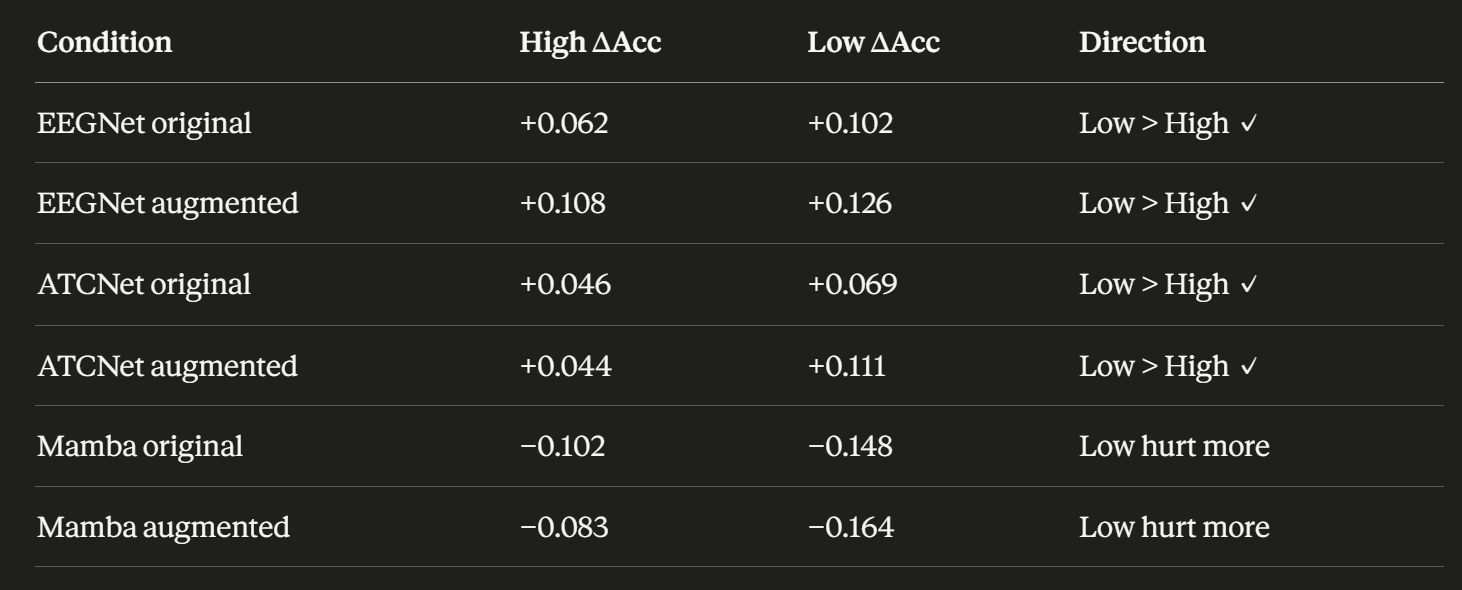

Old data augmentation: augmentation reversed the low-performer advantage for EEGNet. With S&R the low performer advantage is preserved and even strengthened after augmentation. ATCNet augmented shows the largest gap and EEGNet augmented also maintains the direction

Properly implemented augmentation does tend to benefit low performers more, at least directionally

ATCNet with S&R augmentation shows the strongest trend toward disproportionately helping BCI-inefficient subjects

Mamba: with augmentation the penalty for low performers is worse than without augmentation. S&R augmentation actively hurts low performers for Mamba



The S&R method divides each EEG training trial into non-overlapping segments, then creates new synthetic trials by randomly selecting segments from different trials of the same class while maintaining temporal order. Our implenetation does this by splitting 4 second trial into 2 halves (256 sample each at 128 Hz), then for each segment position we randomly pick a donor trial from the same class. Temporal order is preserved because segment 1 always comes before segment 2

Roy et al. demonstrated that S&R significantly outperformed Gaussiannoise, sliding window, and window warping for EEG augmentation (https://www.nature.com/articles/s41598-025-96611-5). The 3x factor (original + 2 synthetic copies) is the standard convention.

Concern with overfitting: EEGNEt augmented results are consistent with literature, mean accuracy of .75 is consistent with the upper range of published EEGNet results on BCI IV-2a, and the per subject rankings are preserved. If the model were overfitting to augmented data you'd expect inflated results for easy subjects but degraded results for hard ones, which isn't what you see



# MOVING ON TO SPECTRAL ANALYSIS

Spectral analysis: looking at the frequency content of the EEG signal and comparing it between high and low performing subjects to give a neurophysiological explanation for why some subjects are hard to classify

When you imagine moving your hand the mu rhythm (8-12 Hz) and beta rhythm (13-30 Hz) over the motor cortex decrease in power. Good BCI subjects show a strong clean ERD that a classifier can detect while poor ones show weaker or noisier ERD

Power spectral density: average frequency spectrum for high vs low performers showing whether mu/beta power differes between groups during motor imagery vs rest

Topographic maps: bird's eye view of the scalp showing where ERD is strongest spatially comparing high vs low performers



In [ ]:
!pip install mne -q

In [ ]:
from scipy.signal import welch
from scipy.signal import resample_poly
from sklearn.preprocessing import StandardScaler

def compute_psd(X_trials, fs=128, nperseg=128):
    """
    X_trials: numpy (N, 22, 512) — trials for one subject
    Returns: freqs (F,), psd (22, F) — mean PSD across trials
    """
    psds = []
    for trial in X_trials:  # trial: (22, 512)
        f, p = welch(trial, fs=fs, nperseg=nperseg, axis=-1)
        psds.append(p)
    return f, np.mean(psds, axis=0)  # average over trials

In [ ]:
DATA_DIR = '/content'
high_subjects = [1, 3, 7, 8, 9]   # 1-indexed
low_subjects  = [2, 4, 5, 6]

class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

# For each group, compute mean PSD per class
def get_group_psd(subject_list, subjectData, subjectDataEVAL, DATA_DIR):
    group_psds = {cls: [] for cls in range(4)}

    for idx in subject_list:
        X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
            subjectData[f'subject{idx:02d}'],
            subjectDataEVAL[f'subject{idx:02d}'],
            f'{DATA_DIR}/A{idx:02d}E.mat'
        )
        for cls in range(4):
            trials = X_tr[y_tr == cls]  # (72, 22, 512)
            freqs, psd = compute_psd(trials)
            group_psds[cls].append(psd)

    # Average across subjects in group
    return freqs, {cls: np.mean(group_psds[cls], axis=0)
                   for cls in range(4)}

freqs, high_psd = get_group_psd(high_subjects, subjectData, subjectDataEVAL, DATA_DIR)
_,    low_psd  = get_group_psd(low_subjects,  subjectData, subjectDataEVAL, DATA_DIR)

In [ ]:
def plot_psd_comparison(freqs, high_psd, low_psd, class_names,
                         channels=[8, 12], channel_names=['C3', 'C4']):
    fig, axes = plt.subplots(len(channels), 4, figsize=(18, 8))
    fig.suptitle('Power Spectral Density: High vs Low Performers\n'
                 'During Motor Imagery Tasks', fontsize=13)

    # Focus on 4-40 Hz (motor imagery relevant range)
    freq_mask = (freqs >= 4) & (freqs <= 40)

    for ch_idx, (ch, ch_name) in enumerate(zip(channels, channel_names)):
        for cls in range(4):
            ax = axes[ch_idx, cls]

            h_psd = high_psd[cls][ch, freq_mask]
            l_psd = low_psd[cls][ch, freq_mask]
            f_plot = freqs[freq_mask]

            ax.plot(f_plot, 10 * np.log10(h_psd),
                    color='steelblue', linewidth=2, label='High performers')
            ax.plot(f_plot, 10 * np.log10(l_psd),
                    color='tomato', linewidth=2, label='Low performers')

            # Shade mu (8-12 Hz) and beta (13-30 Hz) bands
            ax.axvspan(8, 12, alpha=0.15, color='green', label='Mu band')
            ax.axvspan(13, 30, alpha=0.10, color='purple', label='Beta band')

            ax.set_title(f'{class_names[cls]} — {ch_name}')
            ax.set_xlabel('Frequency (Hz)')
            if cls == 0:
                ax.set_ylabel('Power (dB)')
            if ch_idx == 0 and cls == 3:
                ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig('/content/psd_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_psd_comparison(freqs, high_psd, low_psd, class_names)

In [ ]:
import mne

def plot_topomap_comparison(high_psd, low_psd, freqs, band=(8, 30)):
    """
    Plot topographic map of mean power in mu+beta band
    for high vs low performers.
    """
    # BCI IV-2a standard 22-channel layout
    ch_names = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
                'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
                'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
                'P1', 'Pz', 'P2', 'POz']

    info = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')
    info.set_montage('standard_1020')

    band_mask = (freqs >= band[0]) & (freqs <= band[1])

    # Average across all 4 classes for overall motor imagery power
    high_band_power = np.mean(
        [high_psd[cls][:, band_mask].mean(axis=1) for cls in range(4)],
        axis=0)  # (22,)
    low_band_power = np.mean(
        [low_psd[cls][:, band_mask].mean(axis=1) for cls in range(4)],
        axis=0)  # (22,)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Mu+Beta Band Power Topography (8–30 Hz)\n'
                 'During Motor Imagery', fontsize=13)

    vmin = min(high_band_power.min(), low_band_power.min())
    vmax = max(high_band_power.max(), low_band_power.max())

    mne.viz.plot_topomap(high_band_power, info, axes=axes[0],
                          show=False, vlim=(vmin, vmax))
    axes[0].set_title('High Performers')

    mne.viz.plot_topomap(low_band_power, info, axes=axes[1],
                          show=False, vlim=(vmin, vmax))
    axes[1].set_title('Low Performers')

    mne.viz.plot_topomap(high_band_power - low_band_power, info,
                          axes=axes[2], show=False, cmap='RdBu_r')
    axes[2].set_title('Difference (High − Low)')

    plt.tight_layout()
    plt.savefig('/content/topomap_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_topomap_comparison(high_psd, low_psd, freqs)

# SPECTRAL ANALYSIS WITH ERD

In [27]:
def compute_erd(npz_data, fs=250, rest_duration=2, imagery_duration=4):
    """
    Compute ERD% per channel per class for one subject.

    ERD% = (power_imagery - power_rest) / power_rest * 100
    Negative = desynchronization (expected motor imagery response)

    Uses the 2s rest window before each cue onset (event 768 -> event 769/770/771/772)
    at original 250 Hz (no resampling needed for spectral analysis)
    """
    s    = npz_data['s'][:, :22].astype(np.float64)  # (M, 22)
    epos = npz_data['epos'].flatten().astype(int)
    etyp = npz_data['etyp'].flatten().astype(int)

    rest_samples    = int(rest_duration * fs)     # 500 samples
    imagery_samples = int(imagery_duration * fs)  # 1000 samples

    # Mu band (8-12 Hz) and Beta band (13-30 Hz)
    from scipy.signal import welch

    results = {}
    code_to_class = {769: 'left', 770: 'right', 771: 'feet', 772: 'tongue'}

    for code, cls_name in code_to_class.items():
        cue_positions = epos[etyp == code]

        rest_psds    = []
        imagery_psds = []

        for cue_pos in cue_positions:
            rest_start    = cue_pos - rest_samples
            imagery_start = cue_pos

            if rest_start < 0:
                continue

            rest_epoch    = s[rest_start:rest_start + rest_samples, :].T      # (22, 500)
            imagery_epoch = s[imagery_start:imagery_start + imagery_samples, :].T  # (22, 1000)

            # Compute power in mu and beta bands
            f_rest, p_rest = welch(rest_epoch, fs=fs, nperseg=fs, axis=-1)
            f_img,  p_img  = welch(imagery_epoch, fs=fs, nperseg=fs, axis=-1)

            rest_psds.append(p_rest)
            imagery_psds.append(p_img)

        rest_mean    = np.mean(rest_psds, axis=0)     # (22, F)
        imagery_mean = np.mean(imagery_psds, axis=0)  # (22, F)

        results[cls_name] = {
            'freqs': f_rest,
            'rest_psd': rest_mean,
            'imagery_psd': imagery_mean,
            'erd': (imagery_mean - rest_mean) / rest_mean * 100  # ERD%
        }

    return results


def compute_band_erd(erd_result, band=(8, 12)):
    """Extract mean ERD% within a frequency band. Returns (22,) array."""
    freqs = erd_result['freqs']
    mask  = (freqs >= band[0]) & (freqs <= band[1])
    return erd_result['erd'][:, mask].mean(axis=1)  # (22,)

In [28]:
high_subjects = [1, 3, 7, 8, 9]
low_subjects  = [2, 4, 5, 6]

high_erd_mu   = []   # mu band ERD per subject
high_erd_beta = []
low_erd_mu    = []
low_erd_beta  = []

for idx in high_subjects:
    erd = compute_erd(subjectData[f'subject{idx:02d}'])
    # Average ERD across all 4 classes, channel C3 (index 7)
    mu_erd   = np.mean([compute_band_erd(erd[cls], (8,12))[7]
                        for cls in ['left','right','feet','tongue']])
    beta_erd = np.mean([compute_band_erd(erd[cls], (13,30))[7]
                        for cls in ['left','right','feet','tongue']])
    high_erd_mu.append(mu_erd)
    high_erd_beta.append(beta_erd)

for idx in low_subjects:
    erd = compute_erd(subjectData[f'subject{idx:02d}'])
    mu_erd   = np.mean([compute_band_erd(erd[cls], (8,12))[7]
                        for cls in ['left','right','feet','tongue']])
    beta_erd = np.mean([compute_band_erd(erd[cls], (13,30))[7]
                        for cls in ['left','right','feet','tongue']])
    low_erd_mu.append(mu_erd)
    low_erd_beta.append(beta_erd)

print("Mu ERD% at C3:")
print(f"  High performers: {np.mean(high_erd_mu):.1f}%")
print(f"  Low performers:  {np.mean(low_erd_mu):.1f}%")
print("\nBeta ERD% at C3:")
print(f"  High performers: {np.mean(high_erd_beta):.1f}%")
print(f"  Low performers:  {np.mean(low_erd_beta):.1f}%")

Mu ERD% at C3:
  High performers: -4.9%
  Low performers:  18.6%

Beta ERD% at C3:
  High performers: -6.2%
  Low performers:  -0.3%


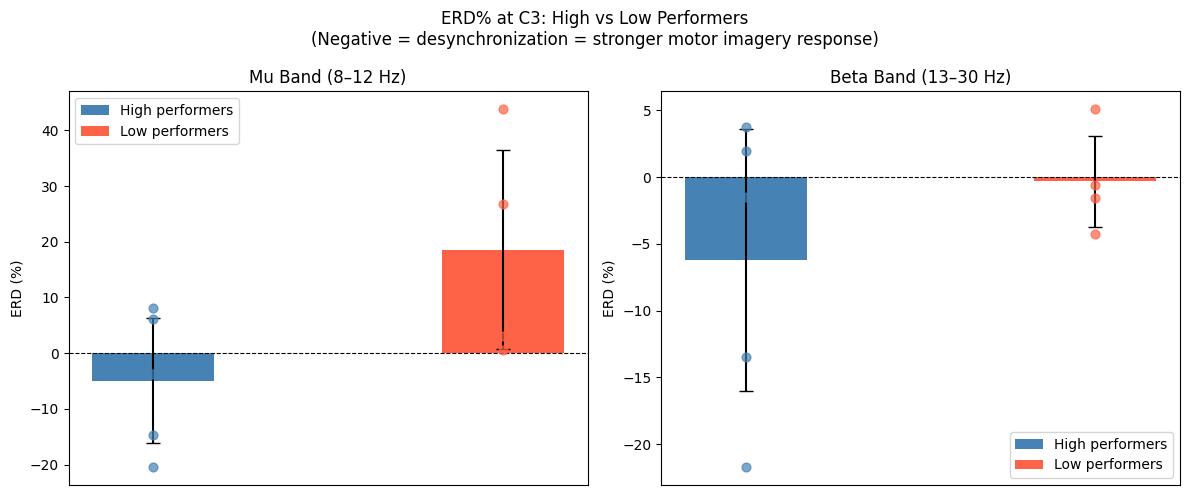

In [29]:
def plot_erd_comparison(high_erd_mu, low_erd_mu, high_erd_beta, low_erd_beta):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('ERD% at C3: High vs Low Performers\n'
                 '(Negative = desynchronization = stronger motor imagery response)',
                 fontsize=12)

    x = np.arange(2)
    width = 0.35

    for ax, high_vals, low_vals, band_name in zip(
        axes,
        [high_erd_mu, high_erd_beta],
        [low_erd_mu,  low_erd_beta],
        ['Mu Band (8–12 Hz)', 'Beta Band (13–30 Hz)']
    ):
        bars_high = ax.bar(x[0], np.mean(high_vals), width,
                           yerr=np.std(high_vals), color='steelblue',
                           label='High performers', capsize=5)
        bars_low  = ax.bar(x[1], np.mean(low_vals),  width,
                           yerr=np.std(low_vals),  color='tomato',
                           label='Low performers',  capsize=5)

        # Plot individual subject points
        ax.scatter(np.full(len(high_vals), x[0]), high_vals,
                   color='steelblue', zorder=5, s=40, alpha=0.7)
        ax.scatter(np.full(len(low_vals),  x[1]), low_vals,
                   color='tomato',    zorder=5, s=40, alpha=0.7)

        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(band_name)
        ax.set_ylabel('ERD (%)')
        ax.set_xticks([])
        ax.legend()

    plt.tight_layout()
    plt.savefig('/content/erd_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_erd_comparison(high_erd_mu, low_erd_mu, high_erd_beta, low_erd_beta)

In [30]:
def get_group_erd_topo(subject_list, subjectData, band=(8, 12)):
    group_erd = []
    for idx in subject_list:
        erd = compute_erd(subjectData[f'subject{idx:02d}'])
        # Average ERD across all 4 classes, all channels
        subj_erd = np.mean([compute_band_erd(erd[cls], band)
                            for cls in ['left','right','feet','tongue']], axis=0)
        group_erd.append(subj_erd)
    return np.mean(group_erd, axis=0)  # (22,)

high_erd_topo = get_group_erd_topo(high_subjects, subjectData, band=(8, 30))
low_erd_topo  = get_group_erd_topo(low_subjects,  subjectData, band=(8, 30))

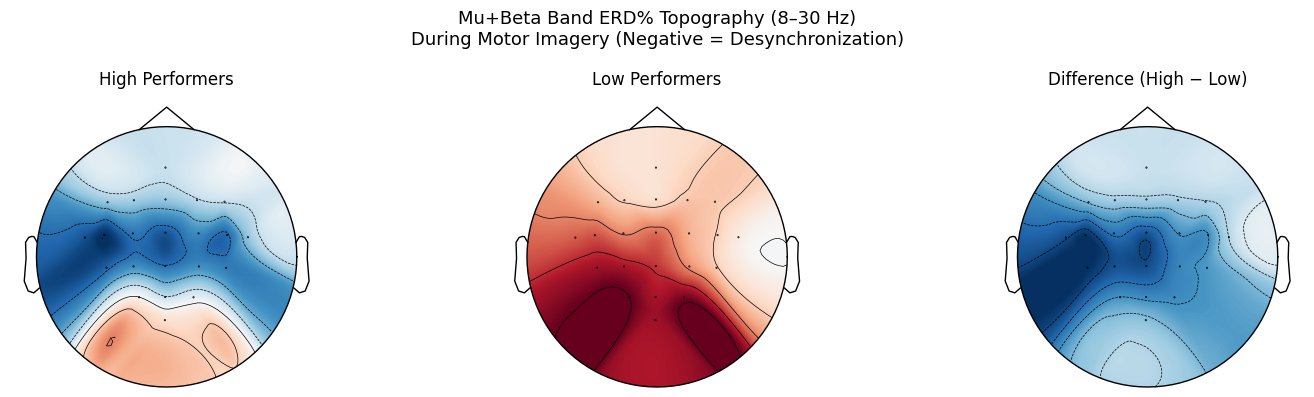

In [32]:
def plot_topomap_erd(high_erd_topo, low_erd_topo):
    """
    Plot topographic map of ERD% in mu+beta band
    for high vs low performers.
    """
    ch_names = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
                'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
                'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
                'P1', 'Pz', 'P2', 'POz']

    info = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')
    info.set_montage('standard_1020')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Mu+Beta Band ERD% Topography (8–30 Hz)\n'
                 'During Motor Imagery (Negative = Desynchronization)',
                 fontsize=13)

    vmin = min(high_erd_topo.min(), low_erd_topo.min())
    vmax = max(high_erd_topo.max(), low_erd_topo.max())

    mne.viz.plot_topomap(high_erd_topo, info, axes=axes[0],
                          show=False, vlim=(vmin, vmax), cmap='RdBu_r')
    axes[0].set_title('High Performers')

    mne.viz.plot_topomap(low_erd_topo, info, axes=axes[1],
                          show=False, vlim=(vmin, vmax), cmap='RdBu_r')
    axes[1].set_title('Low Performers')

    mne.viz.plot_topomap(high_erd_topo - low_erd_topo, info,
                          axes=axes[2], show=False, cmap='RdBu_r')
    axes[2].set_title('Difference (High − Low)')

    plt.tight_layout()
    plt.savefig('/content/erd_topomap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_topomap_erd(high_erd_topo, low_erd_topo)